### Prof. Pedram Jahangiry

You need to make a copy to your own Google drive if you want to edit the original notebook! Start by opening this notebook on Colab 👇

<a href="https://colab.research.google.com/github/PJalgotrader/Deep_Learning-USU/blob/main/Lectures%20and%20codes/Module%203-%20Machine%20Learning%20Review/Module%203-%20ML%20PyCaret-Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



![logo](https://upload.wikimedia.org/wikipedia/commons/4/44/Huntsman-Wordmark-with-USU-Blue.gif#center)


## 🔗 Links

[![linkedin](https://img.shields.io/badge/LinkedIn-0A66C2?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pedram-jahangiry-cfa-5778015a)

[![Youtube](https://img.shields.io/badge/youtube_channel-1DA1F2?style=for-the-badge&logo=youtube&logoColor=white&color=FF0000)](https://www.youtube.com/channel/UCNDElcuuyX-2pSatVBDpJJQ)

[![Twitter URL](https://img.shields.io/twitter/url/https/twitter.com/PedramJahangiry.svg?style=social&label=Follow%20%40PedramJahangiry)](https://twitter.com/PedramJahangiry)


---


# ⚠️ Important: How to run PyCaret (read this first)

**PyCaret requires Python 3.11 or older.** Google Colab's default runtime now uses Python 3.12, so `pip install pycaret` fails there. You have two options:

### Option 1 — Use a previous Colab runtime version
1. Click **Runtime** in the top menu
2. Select **Change runtime type**
3. Under **Runtime version**, change from "Latest (recommended)" to **2025.07** (Python 3.11)
4. Click **Save** — the runtime restarts automatically
5. Verify with `!python --version` (you should see Python 3.11.x), then run the `pip install pycaret` cell below

*Note: Colab keeps past runtime versions for about a year after release. If 2025.07 no longer appears in the list, use Option 2.*

### Option 2 — Run locally with Python 3.11
Create a dedicated environment on your own machine:
```
conda create -n pycaret python=3.11 -y
conda activate pycaret
pip install pycaret
```
Then open this notebook in Jupyter/VS Code using that environment. For detailed setup help, see my PyCaret playlist: https://www.youtube.com/playlist?list=PL2GWo47BFyUOqCAj_16yeNspfeM0nfA6q


# Module3- ML with PyCaret

## Installation

Follow the steps here: https://pycaret.gitbook.io/docs/get-started/installation


In [1]:
!pip install "pycaret==3.3.2" xgboost lightgbm "catboost==1.2.8"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 7.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.3 MB/s eta 0:00:00


In [ ]:
#only if you want to run it in Google Colab:

# !pip install pycaret[full]

In [2]:
# let's double ckeck the Pycaret version:
from pycaret.utils import version
version()

'3.3.2'

## Importing Dataset

In [3]:
from pycaret.datasets import get_data
# try get_data('index') to see the list of all available data.

In [4]:
get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [5]:
dataset = get_data('employee')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left
0,0.38,0.53,2,157,3,0,0,sales,low,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1
2,0.11,0.88,7,272,4,0,0,sales,medium,1
3,0.72,0.87,5,223,5,0,0,sales,low,1
4,0.37,0.52,2,159,3,0,0,sales,low,1


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   promotion_last_5years  14999 non-null  int64  
 7   department             14999 non-null  object 
 8   salary                 14999 non-null  object 
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
dataset.nunique()

,0
satisfaction_level,92
last_evaluation,65
number_project,6
average_montly_hours,215
time_spend_company,8
Work_accident,2
promotion_last_5years,2
department,10
salary,3
left,2


In [8]:
dataset.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'department', 'salary', 'left'],
      dtype='object')

In [9]:

categoricals = ['Work_accident','promotion_last_5years', 'department', 'salary']

In [10]:
# for the sake of time, let's work wity a tiny subsample of data
dataset = dataset.sample(5000)

In [11]:
data = dataset.sample(frac=0.9, random_state=123)
data_unseen = dataset.drop(data.index)

data.reset_index(drop=True, inplace=True)
data_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (4500, 10)
Unseen Data For Predictions: (500, 10)


In [12]:
data.shape

(4500, 10)

In [13]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left
0,0.80,0.80,4,229,4,0,0,sales,low,0
1,0.81,0.62,3,240,6,0,1,sales,low,0
2,0.18,0.62,3,165,4,0,0,technical,medium,0
3,0.60,0.63,5,267,3,0,0,support,low,0
4,0.70,0.54,5,263,3,0,0,technical,low,0


In [14]:
data.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'department', 'salary', 'left'],
      dtype='object')

## Setting up Environment in PyCaret

**setup()**:

This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function. It takes two mandatory parameters: data and target. All the other parameters are optional.

In [15]:
from pycaret.classification import *

The latest version of PyCaret is Object oriented API. This means that the settings are linked with an object, you can run as many experiments as you want in the same notebook and compare them seamlessly not just across different modeling options but also different preprocessing settings.


In [16]:
exp = ClassificationExperiment()
exp.setup(data,  target='left', session_id=555, categorical_features= categoricals, train_size=0.8, preprocess=True)



,Description,Value
0,Session id,555
1,Target,left
2,Target type,Binary
3,Original data shape,"(4500, 10)"
4,Transformed data shape,"(4500, 21)"
5,Transformed train set shape,"(3600, 21)"
6,Transformed test set shape,"(900, 21)"
7,Numeric features,5
8,Categorical features,4
9,Preprocess,True


In [17]:
# list of available models in PyCaret for classification.
exp.models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


## Compare Models

This function trains and evaluates performance of all estimators available in the model library using cross validation. The output of this function is a score grid with average cross validated scores. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function.

In [18]:
exp.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9808,0.9843,0.9420,0.9789,0.9599,0.9473,0.9478,0.6250
xgboost,Extreme Gradient Boosting,0.9786,0.9838,0.9375,0.9744,0.9554,0.9413,0.9418,0.1920
rf,Random Forest Classifier,0.9775,0.9822,0.9250,0.9821,0.9525,0.9378,0.9387,0.6270
catboost,CatBoost Classifier,0.9750,0.9862,0.9250,0.9719,0.9476,0.9312,0.9319,1.9070
et,Extra Trees Classifier,0.9719,0.9825,0.9114,0.9724,0.9407,0.9224,0.9234,0.4170
gbc,Gradient Boosting Classifier,0.9681,0.9841,0.9125,0.9553,0.9331,0.9121,0.9128,0.5500
dt,Decision Tree Classifier,0.9594,0.9524,0.9386,0.9003,0.9187,0.8917,0.8924,0.1140
ada,Ada Boost Classifier,0.9519,0.9769,0.8955,0.9079,0.9009,0.8692,0.8699,0.2920
knn,K Neighbors Classifier,0.9203,0.9578,0.8943,0.8039,0.8456,0.7922,0.7952,0.1340
qda,Quadratic Discriminant Analysis,0.8464,0.8946,0.7852,0.6603,0.7130,0.6099,0.6177,0.1430


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=555, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [19]:
# Adding the list of models we want to include in our study:
model_list = ['lr', 'dt', 'rf', 'xgboost', 'catboost', 'lightgbm']

In [20]:
my_models = exp.compare_models(include=model_list, n_select=6)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9808,0.9843,0.9420,0.9789,0.9599,0.9473,0.9478,1.0080
xgboost,Extreme Gradient Boosting,0.9786,0.9838,0.9375,0.9744,0.9554,0.9413,0.9418,0.1880
rf,Random Forest Classifier,0.9775,0.9822,0.9250,0.9821,0.9525,0.9378,0.9387,0.5940
catboost,CatBoost Classifier,0.9750,0.9862,0.9250,0.9719,0.9476,0.9312,0.9319,1.8670
dt,Decision Tree Classifier,0.9594,0.9524,0.9386,0.9003,0.9187,0.8917,0.8924,0.1330
lr,Logistic Regression,0.7842,0.8186,0.3398,0.6012,0.4318,0.3125,0.3324,0.2470


Processing:   0%|          | 0/34 [00:00<?, ?it/s]

## Tune model

This function tunes the hyperparameters of a given estimator. The output of this function is a score grid with CV scores by fold of the best selected model based on optimize parameter. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function.

In [21]:
data['left'].value_counts()
# data is relatively balanced, we can optimize based on accuracy.

,count
left,
0,3400
1,1100


In [22]:
my_models

[LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=555, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cpu', early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, 

In [23]:
tuned_models = [exp.tune_model(model, optimize='Accuracy') for model in my_models]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9778,0.9914,0.9545,0.9545,0.9545,0.9398,0.9398
1,0.9889,0.9903,0.9545,1.0000,0.9767,0.9695,0.9699
2,0.9750,0.9583,0.9091,0.9877,0.9467,0.9304,0.9318
3,0.9833,0.9839,0.9432,0.9881,0.9651,0.9542,0.9546
4,0.9806,0.9804,0.9432,0.9765,0.9595,0.9467,0.9470
5,0.9806,0.9764,0.9205,1.0000,0.9586,0.9459,0.9473
6,0.9667,0.9866,0.9205,0.9419,0.9310,0.9091,0.9092
7,0.9917,0.9949,0.9659,1.0000,0.9827,0.9772,0.9774
8,0.9722,0.9723,0.9091,0.9756,0.9412,0.9230,0.9240


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9694,0.9881,0.9545,0.9231,0.9385,0.9182,0.9185
1,0.9833,0.9937,0.9659,0.9659,0.9659,0.9549,0.9549
2,0.9556,0.9650,0.9205,0.9000,0.9101,0.8806,0.8807
3,0.9750,0.9806,0.9432,0.9540,0.9486,0.9321,0.9321
4,0.9694,0.9783,0.9432,0.9326,0.9379,0.9176,0.9176
5,0.9806,0.9832,0.9318,0.9880,0.9591,0.9463,0.9470
6,0.9667,0.9839,0.9432,0.9222,0.9326,0.9104,0.9105
7,0.9833,0.9897,0.9545,0.9767,0.9655,0.9545,0.9546
8,0.9694,0.9721,0.9205,0.9529,0.9364,0.9163,0.9166


...

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7806,0.8347,0.3295,0.5918,0.4234,0.3012,0.3209
1,0.8083,0.8445,0.4205,0.6727,0.5175,0.4057,0.4232
2,0.8139,0.7885,0.4318,0.6909,0.5315,0.4230,0.4412
3,0.8028,0.8456,0.3636,0.6809,0.4741,0.3662,0.3935
4,0.7833,0.8313,0.3750,0.5893,0.4583,0.3312,0.3444
5,0.7833,0.7974,0.3409,0.6000,0.4348,0.3131,0.3323
6,0.7583,0.8119,0.1818,0.5161,0.2689,0.1622,0.1941
7,0.7806,0.8455,0.3636,0.5818,0.4476,0.3196,0.3334
8,0.7833,0.7980,0.3636,0.5926,0.4507,0.3253,0.3403


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [24]:
tuned_models

[LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=555, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cpu', early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, 

## Create Model

This function trains and evaluates the performance of a given estimator using cross validation. The output of this function is a score grid with CV scores by fold. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function. All the available models can be accessed using the models function.

In [25]:
# From the above exercise, it seems that the first 3 tuned models (rf, dt and catboost) are the best. Let's create them separately for further visualizations and reports.
rf = exp.create_model('rf')
tuned_rf = exp.tune_model(rf)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9778,0.9847,0.9545,0.9545,0.9545,0.9398,0.9398
1,0.9833,0.9937,0.9318,1.0000,0.9647,0.9538,0.9548
2,0.9528,0.9630,0.8750,0.9277,0.9006,0.8697,0.8703
3,0.9833,0.9763,0.9318,1.0000,0.9647,0.9538,0.9548
4,0.9778,0.9727,0.9205,0.9878,0.9529,0.9384,0.9394
5,0.9778,0.9805,0.9091,1.0000,0.9524,0.9379,0.9397
6,0.9750,0.9870,0.9091,0.9877,0.9467,0.9304,0.9318
7,0.9889,0.9940,0.9545,1.0000,0.9767,0.9695,0.9699
8,0.9667,0.9718,0.8977,0.9634,0.9294,0.9076,0.9086


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9667,0.9863,0.9432,0.9222,0.9326,0.9104,0.9105
1,0.9750,0.9924,0.9205,0.9759,0.9474,0.9310,0.9317
2,0.9361,0.9593,0.8636,0.8736,0.8686,0.8264,0.8264
3,0.9778,0.9721,0.9091,1.0000,0.9524,0.9379,0.9397
4,0.9667,0.9814,0.8977,0.9634,0.9294,0.9076,0.9086
5,0.9611,0.9792,0.8636,0.9744,0.9157,0.8905,0.8932
6,0.9583,0.9798,0.8977,0.9294,0.9133,0.8859,0.8861
7,0.9750,0.9888,0.9091,0.9877,0.9467,0.9304,0.9318
8,0.9639,0.9675,0.9091,0.9412,0.9249,0.9011,0.9013


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [26]:
dt = exp.create_model('dt')
tuned_dt = exp.tune_model(dt)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9528,0.9534,0.9545,0.8660,0.9081,0.8764,0.8783
1,0.9639,0.9684,0.9773,0.8866,0.9297,0.9055,0.9075
2,0.9417,0.9230,0.8864,0.8764,0.8814,0.8427,0.8427
3,0.9583,0.9417,0.9091,0.9195,0.9143,0.8868,0.8868
4,0.9694,0.9644,0.9545,0.9231,0.9385,0.9182,0.9185
5,0.9722,0.9624,0.9432,0.9432,0.9432,0.9248,0.9248
6,0.9472,0.9382,0.9205,0.8710,0.8950,0.8598,0.8604
7,0.9667,0.9664,0.9659,0.9043,0.9341,0.9118,0.9127
8,0.9500,0.9323,0.8977,0.8977,0.8977,0.8646,0.8646


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9722,0.9755,0.9545,0.9333,0.9438,0.9254,0.9255
1,0.9667,0.9857,0.9205,0.9419,0.9310,0.9091,0.9092
2,0.9472,0.9289,0.8636,0.9157,0.8889,0.8543,0.8549
3,0.9694,0.9822,0.9091,0.9639,0.9357,0.9157,0.9163
4,0.9667,0.9652,0.9091,0.9524,0.9302,0.9084,0.9088
5,0.9611,0.9664,0.8864,0.9512,0.9176,0.8922,0.8932
6,0.9722,0.9671,0.8977,0.9875,0.9405,0.9224,0.9242
7,0.9722,0.9698,0.9318,0.9535,0.9425,0.9242,0.9243
8,0.9611,0.9531,0.8636,0.9744,0.9157,0.8905,0.8932


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [27]:
catboost = exp.create_model('catboost')
tuned_catboost = exp.tune_model(catboost)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9694,0.9895,0.9432,0.9326,0.9379,0.9176,0.9176
1,0.9833,0.9952,0.9545,0.9767,0.9655,0.9545,0.9546
2,0.9583,0.9617,0.8977,0.9294,0.9133,0.8859,0.8861
3,0.9833,0.9834,0.9318,1.0000,0.9647,0.9538,0.9548
4,0.9722,0.9878,0.9205,0.9643,0.9419,0.9236,0.9241
5,0.9750,0.9890,0.9091,0.9877,0.9467,0.9304,0.9318
6,0.9722,0.9904,0.9091,0.9756,0.9412,0.9230,0.9240
7,0.9806,0.9893,0.9205,1.0000,0.9586,0.9459,0.9473
8,0.9722,0.9776,0.9091,0.9756,0.9412,0.9230,0.9240


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9778,0.9903,0.9545,0.9545,0.9545,0.9398,0.9398
1,0.9889,0.9913,0.9545,1.0000,0.9767,0.9695,0.9699
2,0.9639,0.9612,0.9091,0.9412,0.9249,0.9011,0.9013
3,0.9833,0.9760,0.9318,1.0000,0.9647,0.9538,0.9548
4,0.9750,0.9838,0.9318,0.9647,0.9480,0.9315,0.9318
5,0.9833,0.9827,0.9318,1.0000,0.9647,0.9538,0.9548
6,0.9722,0.9861,0.9205,0.9643,0.9419,0.9236,0.9241
7,0.9889,0.9898,0.9545,1.0000,0.9767,0.9695,0.9699
8,0.9722,0.9749,0.9091,0.9756,0.9412,0.9230,0.9240


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


The winner is tuned_catboost model for this classificaiton problem.

## Plot Model

This function analyzes the performance of a trained model on holdout set. It may require re-training the model in certain cases

In [28]:
exp.plot_model(tuned_dt, plot = 'parameter')

,Parameters
ccp_alpha,0.0
class_weight,None
criterion,entropy
max_depth,10
max_features,1.0
max_leaf_nodes,None
min_impurity_decrease,0.0002
min_samples_leaf,6
min_samples_split,5
min_weight_fraction_leaf,0.0


In [29]:
exp.plot_model(tuned_catboost, plot = 'parameter')

,Parameters
nan_mode,Min
eval_metric,Logloss
iterations,130
sampling_frequency,PerTree
leaf_estimation_method,Newton
random_score_type,NormalWithModelSizeDecrease
grow_policy,SymmetricTree
penalties_coefficient,1
boosting_type,Plain
model_shrink_mode,Constant


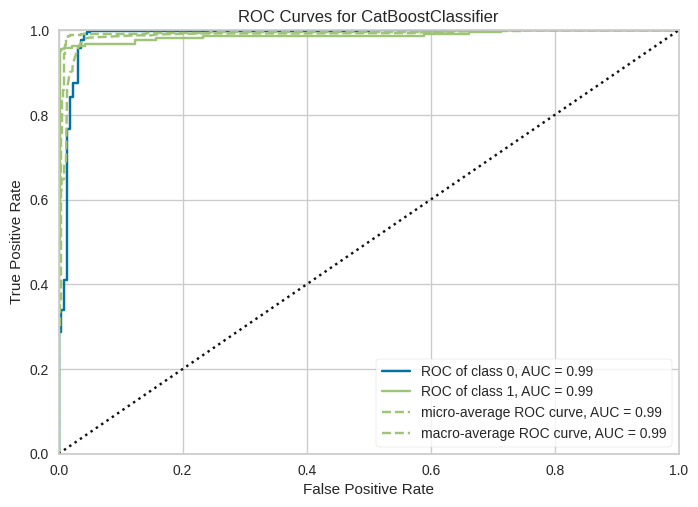

In [30]:
exp.plot_model(tuned_catboost, plot = 'auc')

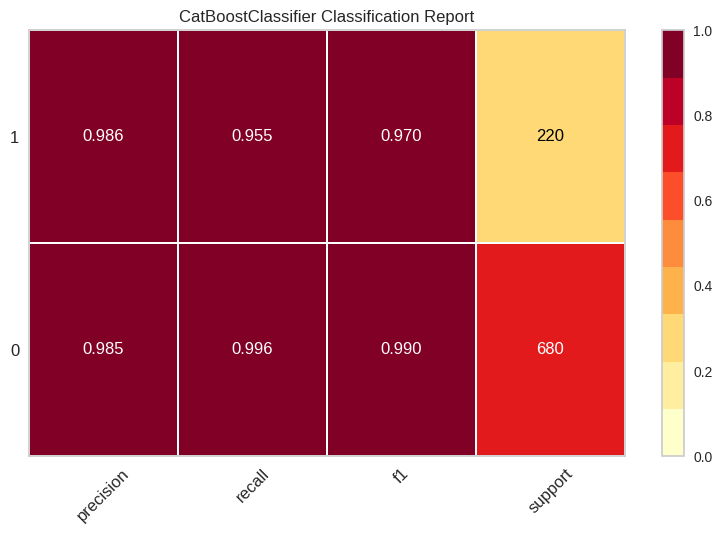

In [31]:
exp.plot_model(tuned_catboost, plot = 'class_report')

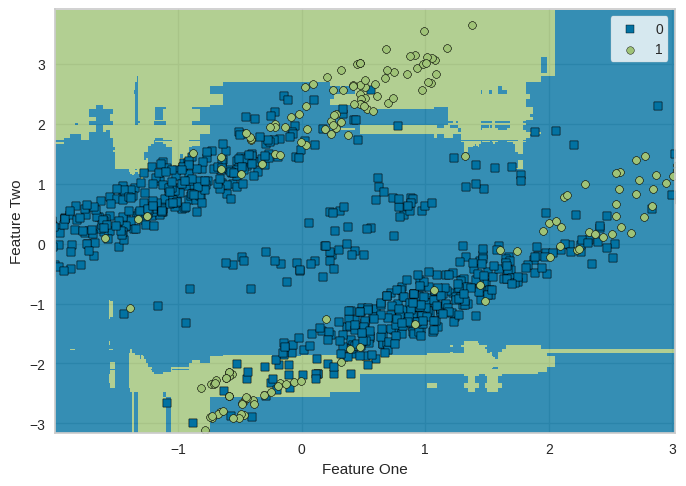

In [32]:
exp.plot_model(tuned_catboost, plot = 'boundary')

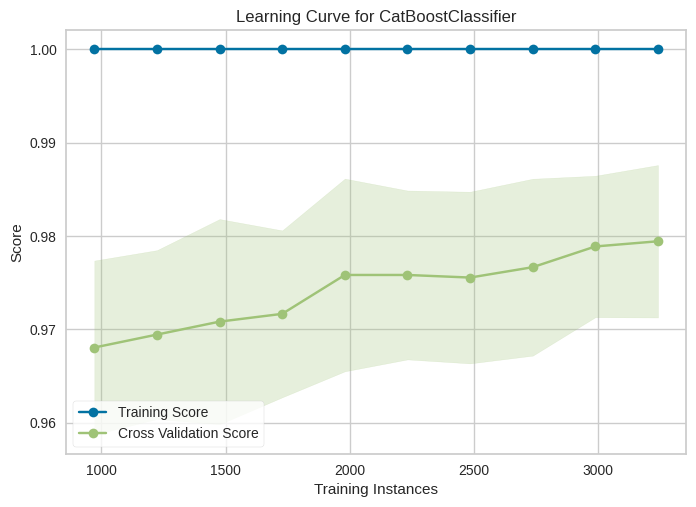

In [33]:
exp.plot_model(tuned_catboost, plot = 'learning')

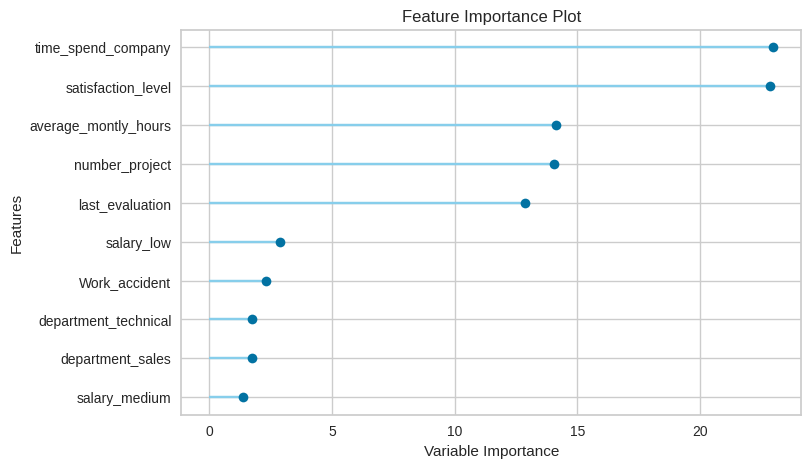

In [34]:
exp.plot_model(tuned_catboost, plot = 'feature')

## Predict Model

This function predicts Label using a trained model. When data is None, it predicts label on the holdout set. In PyCaret terminology, holdout is equivalent to our validation set.

note: so far, our best model is the tuned_catboost model with the highest CV accuracy. :)


In [35]:
holdout_pred = exp.predict_model(tuned_catboost)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.9856,0.9871,0.9545,0.9859,0.9700,0.9605,0.9607


In [36]:
holdout_pred

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,prediction_label,prediction_score
4377,0.90,0.66,3,261,3,1,0,product_mng,medium,0,0,0.9994
879,0.73,0.61,5,222,3,0,0,sales,high,0,0,0.9992
1684,0.90,0.47,2,107,6,1,0,technical,low,0,0,0.9991
4484,0.53,0.64,2,109,3,0,0,hr,medium,0,0,0.9977
1921,0.17,0.94,5,273,4,0,0,technical,medium,0,0,0.9853
...,...,...,...,...,...,...,...,...,...,...,...,...
2620,0.45,0.66,3,111,4,0,0,sales,low,0,0,0.9981
718,0.87,0.88,5,240,5,0,0,IT,medium,1,1,0.9985
3423,0.98,1.00,4,202,3,0,0,support,low,0,0,0.9976
3175,0.63,0.64,5,189,4,0,0,sales,high,0,0,0.9988


## Finalize Model

This function trains a given estimator on the entire dataset including the holdout set.

Model finalization is the last step in the experiment. A normal machine learning workflow in PyCaret starts with setup(), followed by comparing all models using compare_models() and shortlisting a few candidate models (based on the metric of interest) to perform several modeling techniques such as hyperparameter tuning, ensembling, stacking etc. This workflow will eventually lead you to the best model for use in making predictions on new and unseen data. The finalize_model() function fits the model onto the complete dataset including the test/hold-out sample (30% in this case). The purpose of this function is to train the model on the complete dataset before it is deployed in production.

* 5000 total observations
* 4500 used for modeling:
   - 900 is holdout set
   - 3600 is train set
* 500 unseen data

In [37]:
final_model = exp.finalize_model(tuned_catboost)

In [38]:
final_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['satisfaction_level',
                                             'last_evaluation',
                                             'number_project',
                                             'average_montly_hours',
                                             'time_spend_company'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('cate...
                ('onehot_encoding',
                 TransformerWrapper(exclude=None,
                                    include=['department', 'salary'],
                                    transformer=OneHotEncoder(cols=['department',
                                                                    'salary'],
                                                              drop_invariant=False,
                                                              handle_missing='return_nan',
                                                              handle_unknown='value',
                                                              return_df=True,
                                                              use_cat_names=True,
                                                              verbose=0))),
                ('actual_estimator',
                 <catboost.core.CatBoostClassifier object at 0x7d8e2a9b8b10>)],
         verbose=False)

### Final prediciton on unseen data

The predict_model() function is also used to predict on the unseen dataset. The only difference from section 11 above is that this time we will pass the data_unseen parameter. data_unseen is the variable created at the beginning of the tutorial and contains 10% of the original dataset which was never exposed to PyCaret.

In [39]:
unseen_predictions = exp.predict_model(final_model, data=data_unseen)
unseen_predictions

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.9800,0.9895,0.9417,0.9741,0.9576,0.9445,0.9448


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,prediction_label,prediction_score
0,0.11,0.87,7,282,5,0,0,technical,low,1,1,0.9987
1,0.94,0.99,3,207,2,0,0,sales,medium,0,0,0.9987
2,0.94,0.53,5,257,2,0,1,sales,medium,0,0,0.9999
3,0.55,0.93,4,251,4,1,0,RandD,low,0,0,0.9988
4,0.32,0.87,4,179,4,0,0,technical,medium,0,1,0.5150
...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.49,0.36,2,192,3,0,0,sales,low,0,0,0.9998
496,0.74,0.94,4,255,4,0,0,marketing,medium,0,0,0.9895
497,0.11,0.89,6,306,4,0,0,technical,low,1,1,0.9999
498,0.56,0.73,4,148,3,0,0,sales,low,0,0,0.9973


## Save Model

This function saves the transformation pipeline and trained model object into the current working directory as a pickle file for later use.

In [40]:
exp.save_model(final_model, 'my_pycaret_classifier')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['satisfaction_level',
                                              'last_evaluation',
                                              'number_project',
                                              'average_montly_hours',
                                              'time_spend_company'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('cate...
             

## Load model

This function loads a previously saved pipeline.



In [41]:
my_winning_classifier = load_model('my_pycaret_classifier')

Transformation Pipeline and Model Successfully Loaded


In [42]:
my_winning_classifier

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['satisfaction_level',
                                             'last_evaluation',
                                             'number_project',
                                             'average_montly_hours',
                                             'time_spend_company'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('cate...
                ('onehot_encoding',
                 TransformerWrapper(exclude=None,
                                    include=['department', 'salary'],
                                    transformer=OneHotEncoder(cols=['department',
                                                                    'salary'],
                                                              drop_invariant=False,
                                                              handle_missing='return_nan',
                                                              handle_unknown='value',
                                                              return_df=True,
                                                              use_cat_names=True,
                                                              verbose=0))),
                ('actual_estimator',
                 <catboost.core.CatBoostClassifier object at 0x7d8e2a996710>)],
         verbose=False)

Additional Links:

1. https://pycaret.gitbook.io/docs/get-started/quickstart#classification
2. https://pycaret.readthedocs.io/en/stable/api/classification.html PyCaret2.0
3. https://pycaret.readthedocs.io/en/latest/installation.html PyCaret3.0
4. https://towardsdatascience.com/pycaret-3-0-is-coming-soon-whats-new-e890e6a69ff5